🛍️ Sample Buyer Dataset:
    Age  Income  PrevPurchases  Buy
0   56   72733              3    0
1   46   85318              3    1
2   32  109474              0    0
3   60   43664              7    0
4   25   87172              2    1

✅ Accuracy: 0.88

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89        24
           1       0.82      0.88      0.85        16

    accuracy                           0.88        40
   macro avg       0.87      0.88      0.87        40
weighted avg       0.88      0.88      0.88        40



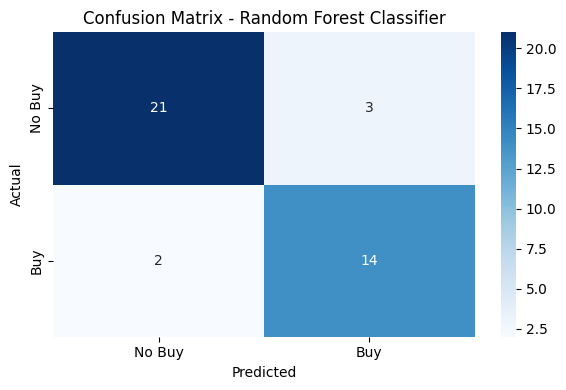

'Output - \n🛍️ Sample Buyer Dataset:\n    Age  Income  PrevPurchases  Buy\n0   56   72733              3    0\n1   46   85318              3    1\n2   32  109474              0    0\n3   60   43664              7    0\n4   25   87172              2    1\n✅ Accuracy: 0.88\n📊 Classification Report:\n               precision    recall  f1-score   support\n           0       0.91      0.88      0.89        24\n           1       0.82      0.88      0.85        16\n    accuracy                           0.88        40\n   macro avg       0.87      0.88      0.87        40\nweighted avg       0.88      0.88      0.88        40\n'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
# Step 1: Generate synthetic classification data
np.random.seed(42)
n_samples = 200
age = np.random.randint(18, 65, size=n_samples)
income = np.random.randint(20000, 120000, size=n_samples)
prev_purchases = np.random.randint(0, 10, size=n_samples)
# Define a simple rule for purchase likelihood
buy = ((income > 50000) & (age < 50) & (prev_purchases >= 2)).astype(int)
# Add noise to make it realistic
noise = np.random.binomial(1, 0.1, size=n_samples)  # 10% noise
y = np.abs(buy - noise)  # flip 10% of labels
# Step 2: Create DataFrame
df = pd.DataFrame({
    'Age': age,
    'Income': income,
    'PrevPurchases': prev_purchases,
    'Buy': y
})
print("🛍️ Sample Buyer Dataset:\n", df.head())
# Step 3: Features and Target
X = df[['Age', 'Income', 'PrevPurchases']]
y = df['Buy']
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Step 5: Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
# Step 6: Predictions and Evaluation
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.2f}")
print("\n📊 Classification Report:\n", report)
# Step 7: Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Buy', 'Buy'], yticklabels=['No Buy', 'Buy'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.tight_layout()
plt.show()
'''Output - 
🛍️ Sample Buyer Dataset:
    Age  Income  PrevPurchases  Buy
0   56   72733              3    0
1   46   85318              3    1
2   32  109474              0    0
3   60   43664              7    0
4   25   87172              2    1
✅ Accuracy: 0.88
📊 Classification Report:
               precision    recall  f1-score   support
           0       0.91      0.88      0.89        24
           1       0.82      0.88      0.85        16
    accuracy                           0.88        40
   macro avg       0.87      0.88      0.87        40
weighted avg       0.88      0.88      0.88        40
'''